# Nome: Tárcila Jéssica Silva de Sousa
# Matrícula: aluno especial

## Import all packages need in the cell below

In [1]:
using Pkg
Pkg.add("Plots")
Pkg.add("Optim")
using Optim
using NLsolve
Pkg.add("AutoGrad")
using AutoGrad
Pkg.add("ForwardDiff")
Pkg.add("LinearAlgebra")

    Updating registry at `C:\Users\tarci\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tarci\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from 

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

Ponto ótimo x* = [3.0, -4.0]
Valor da função em x* = 0.0
Gradiente em x* = [0.0, 0.0]


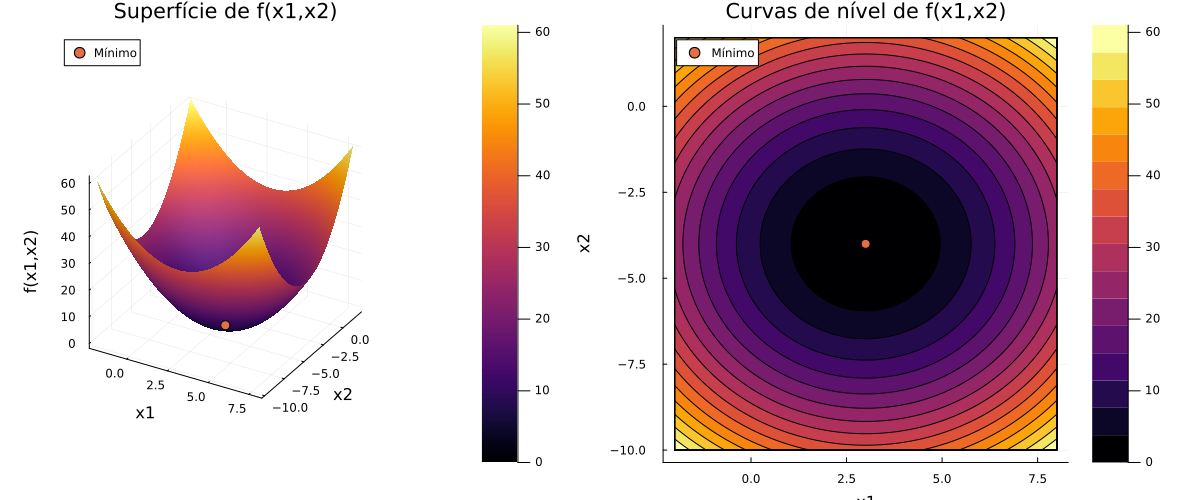

In [6]:
using Pkg
using AutoGrad
using Plots

# f(x) = (x1 - 3)^2 + (x2 + 4)^2
function f(x)
    x1, x2 = x
    return (x1 - 3)^2 + (x2 + 4)^2
end

grad_f = grad(f)

# Ponto que satisfaz a FONC
x_star = [3.0, -4.0]

println("Ponto ótimo x* = ", x_star)
println("Valor da função em x* = ", f(x_star))
println("Gradiente em x* = ", grad_f(x_star))

x1_vals = -2:0.1:8
x2_vals = -10:0.1:2

Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

p1 = surface(
    x1_vals,
    x2_vals,
    Z,
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x1,x2)",
    title = "Superfície de f(x1,x2)",
    legend = true
)

scatter!(
    p1,
    [x_star[1]],
    [x_star[2]],
    [f(x_star)],
    label = "Mínimo",
    markersize = 5
)
p2 = contour(
    x1_vals,
    x2_vals,
    Z,
    xlabel = "x1",
    ylabel = "x2",
    title = "Curvas de nível de f(x1,x2)",
    fill = true,
    legend = true
)

scatter!(
    p2,
    [x_star[1]],
    [x_star[2]],
    label = "Mínimo",
    markersize = 5
)
plot(p1, p2, layout = (1, 2), size = (1200, 500))

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [9]:
using Pkg
# Pkg.add("NLsolve")   # rode apenas uma vez, se ainda não tiver instalado

using NLsolve
using LinearAlgebra
using Printf


# z(x1,x2) = (x1 - 1)^4 + (x2 - 2)^4
# usando NLsolve.jl

function z(x)
    return (x[1] - 1)^4 + (x[2] - 2)^4
end

function grad_z(x)
    return [
        4 * (x[1] - 1)^3,
        4 * (x[2] - 2)^3
    ]
end

function hess_z(x)
    return [
        12 * (x[1] - 1)^2   0.0;
        0.0                 12 * (x[2] - 2)^2
    ]
end

function F!(F, x)
    F[1] = 4 * (x[1] - 1)^3
    F[2] = 4 * (x[2] - 2)^3
end
function J!(J, x)
    J[1,1] = 12 * (x[1] - 1)^2
    J[1,2] = 0.0
    J[2,1] = 0.0
    J[2,2] = 12 * (x[2] - 2)^2
end
x0 = [0.0, 0.0]

sol = nlsolve(F!, J!, x0)

x_num = sol.zero
z_num = z(x_num)
g_num = grad_z(x_num)
H_num = hess_z(x_num)

x_teor = [1.0, 2.0]
z_teor = z(x_teor)
g_teor = grad_z(x_teor)
H_teor = hess_z(x_teor)

println("Resultado usando NLsolve")
println("Convergiu? ", converged(sol))
println("Solução numérica encontrada x* = ", x_num)
println("Valor da função z(x*) = ", z_num)
println("Gradiente em x* = ", g_num)
println("Norma do gradiente = ", norm(g_num))
println("Hessiana em x* = ")
println(H_num)

println("Análise teórica do ponto crítico exato")
println("Ponto crítico exato = ", x_teor)
println("z([1,2]) = ", z_teor)
println("Gradiente em [1,2] = ", g_teor)
println("Hessiana em [1,2] = ")
println(H_teor)

autovalores_teor = eigvals(H_teor)
println("Autovalores da Hessiana em [1,2] = ", autovalores_teor)

println("\nClassificação teórica:")
println("No ponto exato (1,2), a Hessiana é a matriz nula.")
println("Logo, o teste de 2ª ordem é inconclusivo.")

println("\nConclusão final:")
println("Como z(x1,x2) = (x1-1)^4 + (x2-2)^4 >= 0 para todo x,")
println("e z(x1,x2) = 0 somente em (1,2), então x* = [1,2] é o mínimo global da função.")

Resultado usando NLsolve
Convergiu? true
Solução numérica encontrada x* = [0.9995401714125202, 1.9990803428250403]
Valor da função z(x*) = 7.600336005892471e-13
Gradiente em x* = [-3.8890891149869013e-10, -3.111271291989521e-9]
Norma do gradiente = 3.1354838851126693e-9
Hessiana em x* = 
[2.5373079583644365e-6 0.0; 0.0 1.0149231833457746e-5]
Análise teórica do ponto crítico exato
Ponto crítico exato = [1.0, 2.0]
z([1,2]) = 0.0
Gradiente em [1,2] = [0.0, 0.0]
Hessiana em [1,2] = 
[0.0 0.0; 0.0 0.0]
Autovalores da Hessiana em [1,2] = [0.0, 0.0]

Classificação teórica:
No ponto exato (1,2), a Hessiana é a matriz nula.
Logo, o teste de 2ª ordem é inconclusivo.

Conclusão final:
Como z(x1,x2) = (x1-1)^4 + (x2-2)^4 >= 0 para todo x,
e z(x1,x2) = 0 somente em (1,2), então x* = [1,2] é o mínimo global da função.


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

========== RESULTADOS ==========
Ponto mínimo = [3.0, 2.0]
Valor mínimo = 0.0
Gradiente no ponto mínimo = [0.0, 0.0]
Hessiana = 
[2.0 0.0; 0.0 2.0]

========== VERIFICAÇÃO AUTOMÁTICA ==========
Gradiente automático = [0.0, 0.0]
Hessiana automática = 
[2.0 0.0; 0.0 2.0]


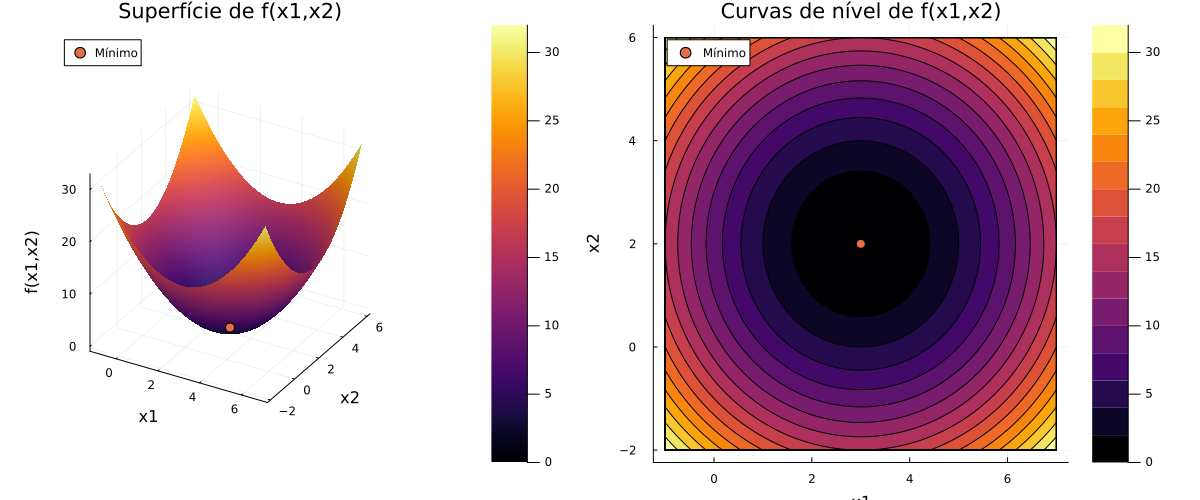

In [1]:
using Pkg
using Plots
using ForwardDiff

# f(x1,x2) = (x1 - 3)^2 + (x2 - 2)^2
function f(x)
    x1, x2 = x
    return (x1 - 3)^2 + (x2 - 2)^2
end

function grad_f(x)
    x1, x2 = x
    return [
        2 * (x1 - 3),
        2 * (x2 - 2)
    ]
end

function hess_f(x)
    return [
        2.0  0.0
        0.0  2.0
    ]
end

x_star = [3.0, 2.0]
f_star = f(x_star)

println("========== RESULTADOS ==========")
println("Ponto mínimo = ", x_star)
println("Valor mínimo = ", f_star)
println("Gradiente no ponto mínimo = ", grad_f(x_star))
println("Hessiana = ")
println(hess_f(x_star))

grad_auto = ForwardDiff.gradient(f, x_star)
hess_auto = ForwardDiff.hessian(f, x_star)

println("\n========== VERIFICAÇÃO AUTOMÁTICA ==========")
println("Gradiente automático = ", grad_auto)
println("Hessiana automática = ")
println(hess_auto)

x1_vals = -1:0.1:7
x2_vals = -2:0.1:6

Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

p1 = surface(
    x1_vals,
    x2_vals,
    Z,
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x1,x2)",
    title = "Superfície de f(x1,x2)",
    legend = true
)

scatter!(
    p1,
    [x_star[1]],
    [x_star[2]],
    [f_star],
    label = "Mínimo",
    markersize = 5
)

p2 = contour(
    x1_vals,
    x2_vals,
    Z,
    xlabel = "x1",
    ylabel = "x2",
    title = "Curvas de nível de f(x1,x2)",
    fill = true,
    legend = true
)

scatter!(
    p2,
    [x_star[1]],
    [x_star[2]],
    label = "Mínimo",
    markersize = 5
)

plot(p1, p2, layout = (1, 2), size = (1200, 500))

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

========== SOLUÇÃO ANALÍTICA ==========
Ponto mínimo esperado = [3.0, 2.0]
Valor mínimo esperado = 0.0

========== GRADIENT DESCENT ==========
Ponto inicial = [1.0, 1.0]
Ponto encontrado = [2.9999999962747097, 1.9999999981373549]
Valor da função = 1.734723475976807e-17
Número de iterações = 29
Gradiente no ponto final = [-7.450580596923828e-9, -3.725290298461914e-9]

========== MÉTODO DE NEWTON ==========
Ponto inicial = [1.0, 1.0]
Ponto encontrado = [3.0, 2.0]
Valor da função = 0.0
Número de iterações = 1
Gradiente no ponto final = [0.0, 0.0]


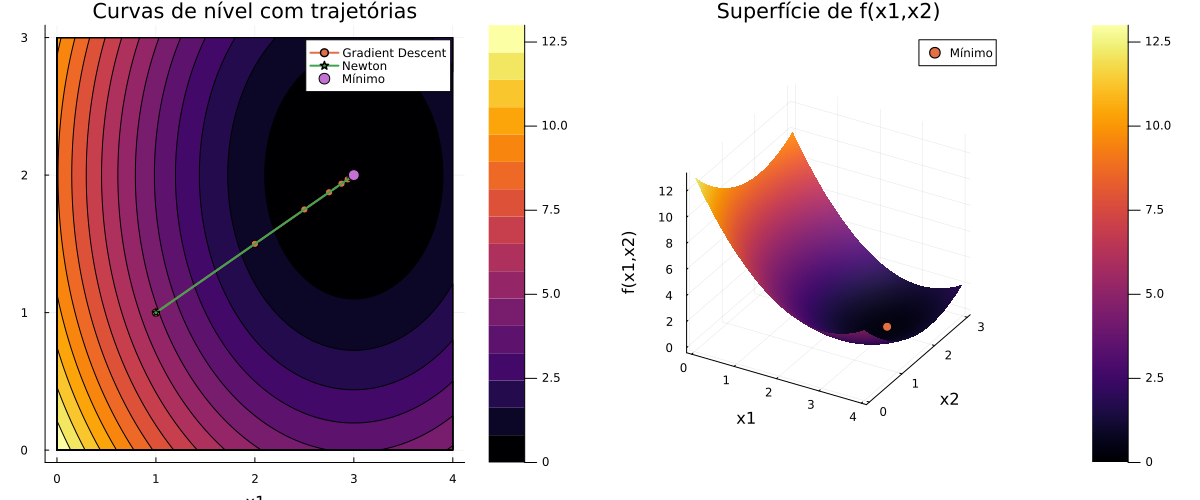

In [2]:
using Pkg
using LinearAlgebra
using Plots

# f(x1,x2) = (x1 - 3)^2 + (x2 - 2)^2

function f(x)
    x1, x2 = x
    return (x1 - 3)^2 + (x2 - 2)^2
end

function grad_f(x)
    x1, x2 = x
    return [
        2 * (x1 - 3),
        2 * (x2 - 2)
    ]
end

function hess_f(x)
    return [
        2.0  0.0
        0.0  2.0
    ]
end

function gradient_descent(f, grad_f, x0; α = 0.25, tol = 1e-8, maxiter = 100)
    x = copy(x0)
    path = [copy(x)]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) < tol
            return x, f(x), k - 1, path
        end

        x = x - α * g
        push!(path, copy(x))
    end

    return x, f(x), maxiter, path
end

function newton_method(f, grad_f, hess_f, x0; tol = 1e-8, maxiter = 20)
    x = copy(x0)
    path = [copy(x)]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) < tol
            return x, f(x), k - 1, path
        end

        H = hess_f(x)
        d = -H \ g
        x = x + d
        push!(path, copy(x))
    end

    return x, f(x), maxiter, path
end

x0 = [1.0, 1.0]

x_star = [3.0, 2.0]
f_star = f(x_star)

println("========== SOLUÇÃO ANALÍTICA ==========")
println("Ponto mínimo esperado = ", x_star)
println("Valor mínimo esperado = ", f_star)


x_gd, f_gd, iter_gd, path_gd = gradient_descent(f, grad_f, x0; α = 0.25, tol = 1e-8, maxiter = 100)

println("\n========== GRADIENT DESCENT ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_gd)
println("Valor da função = ", f_gd)
println("Número de iterações = ", iter_gd)
println("Gradiente no ponto final = ", grad_f(x_gd))

x_nt, f_nt, iter_nt, path_nt = newton_method(f, grad_f, hess_f, x0; tol = 1e-8, maxiter = 20)

println("\n========== MÉTODO DE NEWTON ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_nt)
println("Valor da função = ", f_nt)
println("Número de iterações = ", iter_nt)
println("Gradiente no ponto final = ", grad_f(x_nt))

x1_vals = 0:0.05:4
x2_vals = 0:0.05:3

Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

# Coordenadas do caminho do GD
x_gd_vals = [p[1] for p in path_gd]
y_gd_vals = [p[2] for p in path_gd]

# Coordenadas do caminho do Newton
x_nt_vals = [p[1] for p in path_nt]
y_nt_vals = [p[2] for p in path_nt]


p1 = contour(
    x1_vals,
    x2_vals,
    Z,
    fill = true,
    xlabel = "x1",
    ylabel = "x2",
    title = "Curvas de nível com trajetórias",
    label = ""
)

plot!(
    p1,
    x_gd_vals,
    y_gd_vals,
    marker = :circle,
    linewidth = 2,
    label = "Gradient Descent"
)

plot!(
    p1,
    x_nt_vals,
    y_nt_vals,
    marker = :star5,
    linewidth = 2,
    label = "Newton"
)

scatter!(
    p1,
    [x_star[1]],
    [x_star[2]],
    label = "Mínimo",
    markersize = 6
)

p2 = surface(
    x1_vals,
    x2_vals,
    Z,
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x1,x2)",
    title = "Superfície de f(x1,x2)",
    label = ""
)

scatter!(
    p2,
    [x_star[1]],
    [x_star[2]],
    [f_star],
    label = "Mínimo",
    markersize = 5
)

plot(p1, p2, layout = (1, 2), size = (1200, 500))

Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

========== SOLUÇÃO ANALÍTICA ==========
Ponto mínimo esperado = [3.0, 2.0]
Valor mínimo esperado = 0.0
Gradiente no mínimo = [0.0, 0.0]
Hessiana = 
[20.0 0.0; 0.0 4.0]

========== GRADIENT DESCENT ==========
Ponto inicial = [1.0, 1.0]
Ponto encontrado = [2.99999999999418, 1.9999999980480734]
Valor da função = 7.620373761804165e-18
Número de iterações = 52
Gradiente no ponto final = [-1.1639578190170141e-10, -7.807706481344212e-9]

========== MÉTODO DE NEWTON ==========
Ponto inicial = [1.0, 1.0]
Ponto encontrado = [3.0, 2.0]
Valor da função = 0.0
Número de iterações = 1
Gradiente no ponto final = [0.0, 0.0]


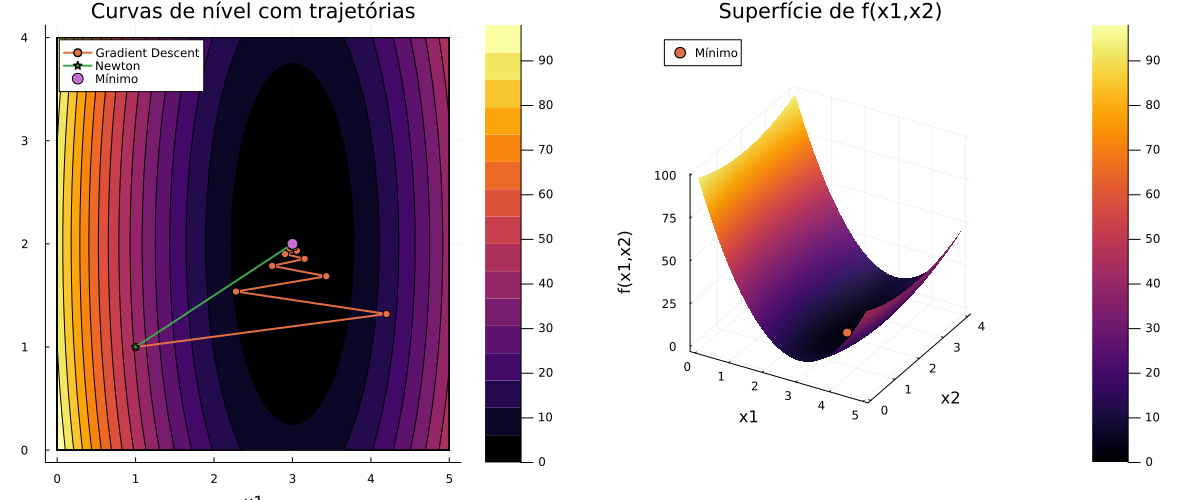

In [3]:
using Pkg
using LinearAlgebra
using Plots

# Definição da função
# f(x1,x2) = 10(x1 - 3)^2 + 2(x2 - 2)^2

function f(x)
    x1, x2 = x
    return 10 * (x1 - 3)^2 + 2 * (x2 - 2)^2
end

function grad_f(x)
    x1, x2 = x
    return [
        20 * (x1 - 3),
        4 * (x2 - 2)
    ]
end

function hess_f(x)
    return [
        20.0  0.0
        0.0   4.0
    ]
end

function gradient_descent(f, grad_f, x0; α = 0.08, tol = 1e-8, maxiter = 200)
    x = copy(x0)
    path = [copy(x)]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) < tol
            return x, f(x), k - 1, path
        end

        x = x - α * g
        push!(path, copy(x))
    end

    return x, f(x), maxiter, path
end

function newton_method(f, grad_f, hess_f, x0; tol = 1e-8, maxiter = 20)
    x = copy(x0)
    path = [copy(x)]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) < tol
            return x, f(x), k - 1, path
        end

        H = hess_f(x)
        d = -H \ g
        x = x + d
        push!(path, copy(x))
    end

    return x, f(x), maxiter, path
end

x0 = [1.0, 1.0]

x_star = [3.0, 2.0]
f_star = f(x_star)

println("========== SOLUÇÃO ANALÍTICA ==========")
println("Ponto mínimo esperado = ", x_star)
println("Valor mínimo esperado = ", f_star)
println("Gradiente no mínimo = ", grad_f(x_star))
println("Hessiana = ")
println(hess_f(x_star))


x_gd, f_gd, iter_gd, path_gd = gradient_descent(f, grad_f, x0; α = 0.08, tol = 1e-8, maxiter = 200)

println("\n========== GRADIENT DESCENT ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_gd)
println("Valor da função = ", f_gd)
println("Número de iterações = ", iter_gd)
println("Gradiente no ponto final = ", grad_f(x_gd))

x_nt, f_nt, iter_nt, path_nt = newton_method(f, grad_f, hess_f, x0; tol = 1e-8, maxiter = 20)

println("\n========== MÉTODO DE NEWTON ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_nt)
println("Valor da função = ", f_nt)
println("Número de iterações = ", iter_nt)
println("Gradiente no ponto final = ", grad_f(x_nt))

x1_vals = 0:0.05:5
x2_vals = 0:0.05:4

Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

# Caminho do Gradient Descent
x_gd_vals = [p[1] for p in path_gd]
y_gd_vals = [p[2] for p in path_gd]

# Caminho do Newton
x_nt_vals = [p[1] for p in path_nt]
y_nt_vals = [p[2] for p in path_nt]

p1 = contour(
    x1_vals,
    x2_vals,
    Z,
    fill = true,
    xlabel = "x1",
    ylabel = "x2",
    title = "Curvas de nível com trajetórias",
    label = ""
)

plot!(
    p1,
    x_gd_vals,
    y_gd_vals,
    marker = :circle,
    linewidth = 2,
    label = "Gradient Descent"
)

plot!(
    p1,
    x_nt_vals,
    y_nt_vals,
    marker = :star5,
    linewidth = 2,
    label = "Newton"
)

scatter!(
    p1,
    [x_star[1]],
    [x_star[2]],
    label = "Mínimo",
    markersize = 6
)

p2 = surface(
    x1_vals,
    x2_vals,
    Z,
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x1,x2)",
    title = "Superfície de f(x1,x2)",
    label = ""
)

scatter!(
    p2,
    [x_star[1]],
    [x_star[2]],
    [f_star],
    label = "Mínimo",
    markersize = 5
)

plot(p1, p2, layout = (1, 2), size = (1200, 500))

Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

========== SOLUÇÃO ANALÍTICA ==========
Ponto mínimo esperado = [0.0, 0.0]
Valor mínimo esperado = 0.0
Gradiente no mínimo = [0.0, 0.0]
Hessiana = 
[2.0 0.0; 0.0 2.0]

========== GRADIENT DESCENT ==========
Ponto inicial = [-2.0, 2.0]
Ponto encontrado = [-1.862645149230957e-9, 1.862645149230957e-9]
Valor da função = 6.938893903907228e-18
Número de iterações = 30
Gradiente no ponto final = [-3.725290298461914e-9, 3.725290298461914e-9]

========== MÉTODO DE NEWTON ==========
Ponto inicial = [-2.0, 2.0]
Ponto encontrado = [0.0, 0.0]
Valor da função = 0.0
Número de iterações = 1
Gradiente no ponto final = [0.0, 0.0]


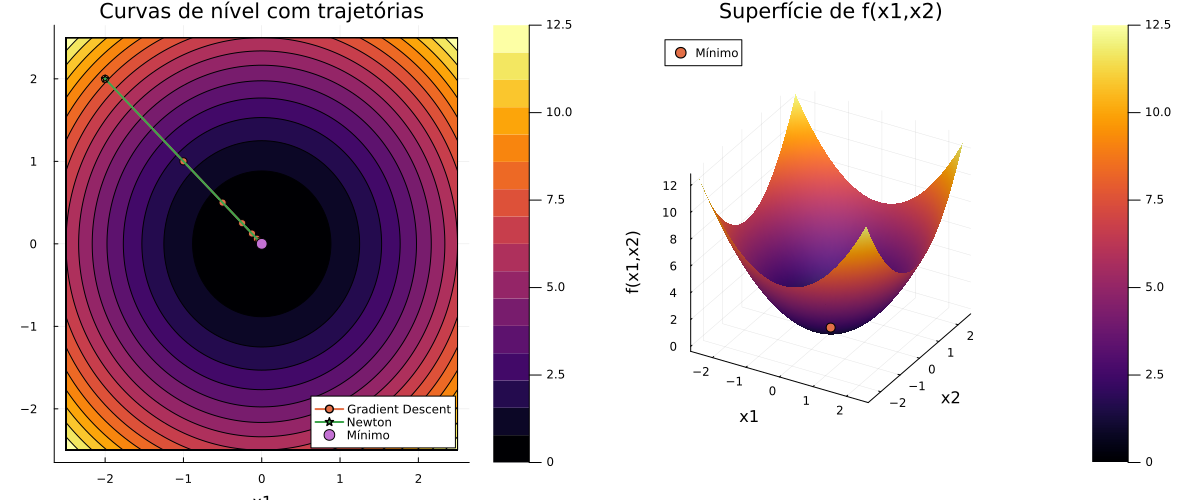

In [4]:
using Pkg
using LinearAlgebra
using Plots

# f(x1,x2) = x1^2 + x2^2

function f(x)
    x1, x2 = x
    return x1^2 + x2^2
end

function grad_f(x)
    x1, x2 = x
    return [
        2*x1,
        2*x2
    ]
end

function hess_f(x)
    return [
        2.0  0.0
        0.0  2.0
    ]
end

function gradient_descent(f, grad_f, x0; α = 0.25, tol = 1e-8, maxiter = 100)
    x = copy(x0)
    path = [copy(x)]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) < tol
            return x, f(x), k - 1, path
        end

        x = x - α * g
        push!(path, copy(x))
    end

    return x, f(x), maxiter, path
end

function newton_method(f, grad_f, hess_f, x0; tol = 1e-8, maxiter = 20)
    x = copy(x0)
    path = [copy(x)]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) < tol
            return x, f(x), k - 1, path
        end

        H = hess_f(x)
        d = -H \ g
        x = x + d
        push!(path, copy(x))
    end

    return x, f(x), maxiter, path
end

x0 = [-2.0, 2.0]

x_star = [0.0, 0.0]
f_star = f(x_star)

println("========== SOLUÇÃO ANALÍTICA ==========")
println("Ponto mínimo esperado = ", x_star)
println("Valor mínimo esperado = ", f_star)
println("Gradiente no mínimo = ", grad_f(x_star))
println("Hessiana = ")
println(hess_f(x_star))

x_gd, f_gd, iter_gd, path_gd = gradient_descent(f, grad_f, x0; α = 0.25, tol = 1e-8, maxiter = 100)

println("\n========== GRADIENT DESCENT ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_gd)
println("Valor da função = ", f_gd)
println("Número de iterações = ", iter_gd)
println("Gradiente no ponto final = ", grad_f(x_gd))

x_nt, f_nt, iter_nt, path_nt = newton_method(f, grad_f, hess_f, x0; tol = 1e-8, maxiter = 20)

println("\n========== MÉTODO DE NEWTON ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_nt)
println("Valor da função = ", f_nt)
println("Número de iterações = ", iter_nt)
println("Gradiente no ponto final = ", grad_f(x_nt))

x1_vals = -2.5:0.05:2.5
x2_vals = -2.5:0.05:2.5

Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

# Caminho do Gradient Descent
x_gd_vals = [p[1] for p in path_gd]
y_gd_vals = [p[2] for p in path_gd]

# Caminho do Newton
x_nt_vals = [p[1] for p in path_nt]
y_nt_vals = [p[2] for p in path_nt]

p1 = contour(
    x1_vals,
    x2_vals,
    Z,
    fill = true,
    xlabel = "x1",
    ylabel = "x2",
    title = "Curvas de nível com trajetórias",
    label = ""
)

plot!(
    p1,
    x_gd_vals,
    y_gd_vals,
    marker = :circle,
    linewidth = 2,
    label = "Gradient Descent"
)

plot!(
    p1,
    x_nt_vals,
    y_nt_vals,
    marker = :star5,
    linewidth = 2,
    label = "Newton"
)

scatter!(
    p1,
    [x_star[1]],
    [x_star[2]],
    label = "Mínimo",
    markersize = 6
)

p2 = surface(
    x1_vals,
    x2_vals,
    Z,
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x1,x2)",
    title = "Superfície de f(x1,x2)",
    label = ""
)

scatter!(
    p2,
    [x_star[1]],
    [x_star[2]],
    [f_star],
    label = "Mínimo",
    markersize = 5
)
plot(p1, p2, layout = (1, 2), size = (1200, 500))

Implement the same methods for the function f(x) = x_1^2 + 100x_2^2. Use as start point x_0 = [-2.0, 2.0]

========== SOLUÇÃO ANALÍTICA ==========
Ponto mínimo esperado = [0.0, 0.0]
Valor mínimo esperado = 0.0
Gradiente no mínimo = [0.0, 0.0]
Hessiana = 
[2.0 0.0; 0.0 200.0]

========== GRADIENT DESCENT ==========
Ponto inicial = [-2.0, 2.0]
Ponto encontrado = [-4.950660800478637e-9, -3.7342707584453625e-106]
Valor da função = 2.4509042361395777e-17
Número de iterações = 1091

========== MÉTODO DE NEWTON ==========
Ponto inicial = [-2.0, 2.0]
Ponto encontrado = [0.0, 0.0]
Valor da função = 0.0
Número de iterações = 1


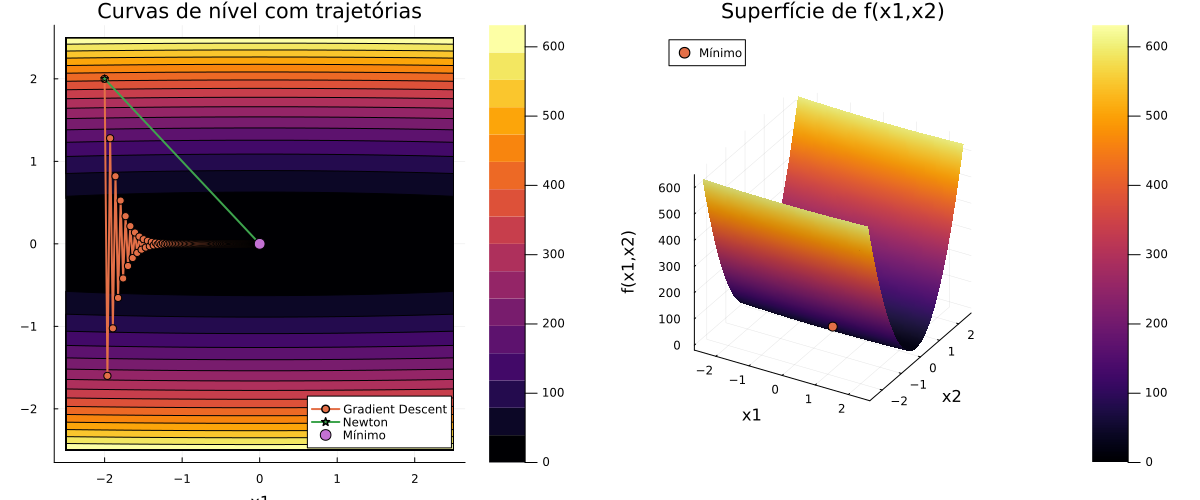

In [4]:
using Pkg
using LinearAlgebra
using Plots

# f(x1,x2) = x1^2 + 100*x2^2
function f(x)
    x1, x2 = x
    return x1^2 + 100 * x2^2
end

function grad_f(x)
    x1, x2 = x
    return [
        2 * x1,
        200 * x2
    ]
end

function hess_f(x)
    return [
        2.0    0.0
        0.0  200.0
    ]
end

# α = 0.009 < 2/200 = 0.01  →  garante convergência
function gradient_descent(f, grad_f, x0; α = 0.009, tol = 1e-8, maxiter = 2000)
    x = copy(x0)
    path = [copy(x)]
    for k in 1:maxiter
        g = grad_f(x)
        if norm(g) < tol
            return x, f(x), k - 1, path
        end
        x = x - α * g
        push!(path, copy(x))
    end
    return x, f(x), maxiter, path
end

function newton_method(f, grad_f, hess_f, x0; tol = 1e-8, maxiter = 20)
    x = copy(x0)
    path = [copy(x)]
    for k in 1:maxiter
        g = grad_f(x)
        if norm(g) < tol
            return x, f(x), k - 1, path
        end
        H = hess_f(x)
        d = -H \ g
        x = x + d
        push!(path, copy(x))
    end
    return x, f(x), maxiter, path
end

x0 = [-2.0, 2.0]
x_star = [0.0, 0.0]
f_star = f(x_star)

println("========== SOLUÇÃO ANALÍTICA ==========")
println("Ponto mínimo esperado = ", x_star)
println("Valor mínimo esperado = ", f_star)
println("Gradiente no mínimo = ", grad_f(x_star))
println("Hessiana = ")
println(hess_f(x_star))

x_gd, f_gd, iter_gd, path_gd = gradient_descent(f, grad_f, x0)

println("\n========== GRADIENT DESCENT ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_gd)
println("Valor da função = ", f_gd)
println("Número de iterações = ", iter_gd)

x_nt, f_nt, iter_nt, path_nt = newton_method(f, grad_f, hess_f, x0)

println("\n========== MÉTODO DE NEWTON ==========")
println("Ponto inicial = ", x0)
println("Ponto encontrado = ", x_nt)
println("Valor da função = ", f_nt)
println("Número de iterações = ", iter_nt)

x1_vals = -2.5:0.05:2.5
x2_vals = -2.5:0.05:2.5
Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

x_gd_vals = [p[1] for p in path_gd]
y_gd_vals = [p[2] for p in path_gd]
x_nt_vals = [p[1] for p in path_nt]
y_nt_vals = [p[2] for p in path_nt]

p1 = contour(x1_vals, x2_vals, Z, fill=true,
    xlabel="x1", ylabel="x2",
    title="Curvas de nível com trajetórias", label="")
plot!(p1, x_gd_vals, y_gd_vals, marker=:circle, linewidth=2, label="Gradient Descent")
plot!(p1, x_nt_vals, y_nt_vals, marker=:star5, linewidth=2, label="Newton")
scatter!(p1, [x_star[1]], [x_star[2]], label="Mínimo", markersize=6)

p2 = surface(x1_vals, x2_vals, Z,
    xlabel="x1", ylabel="x2", zlabel="f(x1,x2)",
    title="Superfície de f(x1,x2)", label="")
scatter!(p2, [x_star[1]], [x_star[2]], [f_star], label="Mínimo", markersize=5)

plot(p1, p2, layout=(1, 2), size=(1200, 500))



For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [10]:
using LinearAlgebra
using Printf

# ============================================================
# Função original
# f(x1,x2,x3) = x3*log(exp(x1/x3) + exp(x2/x3)) + (x3-2)^2 + exp(1/(x1+x2))
# Domínio: x1 + x2 > 0, x3 > 0
# ============================================================

function f_original(x1, x2, x3)
    if x1 + x2 <= 0 || x3 <= 0
        return Inf
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)
    lse = m + log(exp(a - m) + exp(b - m))   # log-sum-exp estável

    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

# ------------------------------------------------------------
# Gradiente da função original
# ------------------------------------------------------------
function grad_original(x1, x2, x3)
    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError((x1,x2,x3), "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)

    ea = exp(a - m)
    eb = exp(b - m)
    S  = ea + eb

    p1 = ea / S
    p2 = eb / S
    logS = m + log(S)

    s = x1 + x2
    eC = exp(1 / s)
    termC = eC / s^2

    g1 = p1 - termC
    g2 = p2 - termC
    g3 = logS - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2)

    return [g1, g2, g3]
end

# ============================================================
# Mudança de variáveis: x2 = y2 / 10
# F(x1,y2,x3) = f(x1, y2/10, x3)
# ============================================================

function F(v::AbstractVector)
    x1, y2, x3 = v
    return f_original(x1, y2 / 10, x3)
end

function grad_F(v::AbstractVector)
    x1, y2, x3 = v
    g = grad_original(x1, y2 / 10, x3)

    # regra da cadeia:
    # dF/dx1 = df/dx1
    # dF/dy2 = (df/dx2)*(dx2/dy2) = (1/10) df/dx2
    # dF/dx3 = df/dx3
    return [g[1], g[2] / 10, g[3]]
end

# ------------------------------------------------------------
# Domínio nas variáveis transformadas
# x1 + y2/10 > 0, x3 > 0
# ------------------------------------------------------------
function in_domain_F(v::AbstractVector)
    x1, y2, x3 = v
    return (x1 + y2 / 10 > 0) && (x3 > 0)
end

# ------------------------------------------------------------
# Backtracking line search nas variáveis transformadas
# ------------------------------------------------------------
function backtracking_F(F, grad_F, v; α=0.4, β=0.5, t_min=1e-20, maxiter=200)
    if !(0 < α < 0.5)
        error("É preciso ter 0 < α < 0.5")
    end
    if !(0 < β < 1)
        error("É preciso ter 0 < β < 1")
    end
    if !in_domain_F(v)
        error("O ponto inicial não pertence ao domínio.")
    end

    g = grad_F(v)
    Δv = -g
    fv = F(v)
    t = 1.0

    for _ in 1:maxiter
        v_trial = v .+ t .* Δv

        if in_domain_F(v_trial) && F(v_trial) <= fv + α * t * dot(g, Δv)
            return t
        end

        t *= β

        if t < t_min
            return t
        end
    end

    return t
end

# ------------------------------------------------------------
# Gradient Descent com Backtracking
# ------------------------------------------------------------
function gradient_descent_backtracking(F, grad_F, v0; α=0.4, β=0.5, eps=1e-5, maxiter=10_000)
    v = copy(v0)

    vs = [copy(v)]
    fs = [F(v)]
    ts = Float64[]

    for k in 1:maxiter
        g = grad_F(v)

        if norm(g) <= eps
            return v, vs, fs, ts, k - 1
        end

        t = backtracking_F(F, grad_F, v; α=α, β=β)
        v = v .- t .* g

        push!(vs, copy(v))
        push!(fs, F(v))
        push!(ts, t)
    end

    return v, vs, fs, ts, maxiter
end

# ============================================================
# Parâmetros do enunciado
# ============================================================
α = 0.4
β = 0.5
eps = 1e-5

# ponto inicial original: x0 = [3, 4, 5]
# como x2 = y2/10, então y2 = 10*x2 = 40
v0 = [3.0, 40.0, 5.0]

# ------------------------------------------------------------
# Execução
# ------------------------------------------------------------
vmin, vs, fs, ts, iters = gradient_descent_backtracking(
    F, grad_F, v0;
    α=α, β=β, eps=eps
)

# converte de volta para as variáveis originais
xmin = [vmin[1], vmin[2] / 10, vmin[3]]

println("========== Gradient Descent with Backtracking ==========")
println("Variáveis transformadas: v = (x1, y2, x3)")
println("Ponto inicial transformado v0 = ", v0)
println("Ponto inicial original x0     = ", [v0[1], v0[2]/10, v0[3]])

println("\nSolução nas variáveis transformadas:")
println("vmin = ", vmin)

println("\nSolução nas variáveis originais:")
println("xmin = ", xmin)

@printf("\nF(vmin) = %.10f\n", F(vmin))
@printf("f(xmin) = %.10f\n", f_original(xmin[1], xmin[2], xmin[3]))
@printf("||∇F(vmin)|| = %.6e\n", norm(grad_F(vmin)))
println("Número de iterações = ", iters)

if !isempty(ts)
    println("\nÚltimos step sizes:")
    println(ts[max(1, end-4):end])
end

========== Gradient Descent with Backtracking ==========
Variáveis transformadas: v = (x1, y2, x3)
Ponto inicial transformado v0 = [3.0, 40.0, 5.0]
Ponto inicial original x0     = [3.0, 4.0, 5.0]

Solução nas variáveis transformadas:
vmin = [0.9260791871578731, 9.26409702959696, 1.6534264122269975]

Solução nas variáveis originais:
xmin = [0.9260791871578731, 0.9264097029596959, 1.6534264122269975]

F(vmin) = 3.9081137963
f(xmin) = 3.9081137963
||∇F(vmin)|| = 9.951550e-06
Número de iterações = 2085

Últimos step sizes:
[1.0, 1.0, 1.0, 1.0, 1.0]


Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [10]:
using LinearAlgebra
using Printf

# ---------- Função objetivo com verificação de domínio ----------
function f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)                                  # log-sum-exp estável
    lse = m + log(exp(a - m) + exp(b - m))         # = log(e^(x1/x3) + e^(x2/x3))

    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

# ---------- Gradiente analítico com verificação de domínio ----------
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    # --- exponenciais em forma numericamente estável ---
    a = x1 / x3
    b = x2 / x3
    m = max(a, b)

    ea = exp(a - m)           # proporcional a e^(x1/x3)
    eb = exp(b - m)           # proporcional a e^(x2/x3)
    S  = ea + eb

    # --- razões softmax ---
    p1 = ea / S
    p2 = eb / S

    # --- log-soma estável ---
    log_sum = m + log(S)

    # --- termo exp(1 / (x1 + x2)) ---
    t = x1 + x2
    eC = exp(1 / t)
    termC = eC / (t^2)

    # --- componentes do gradiente ---
    df_dx1 = p1 - termC
    df_dx2 = p2 - termC
    df_dx3 = log_sum - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

# ============================================================
# Gradiente numérico por diferenças finitas centradas
# ============================================================
function grad_numerico(f, x; h = 1e-6)
    n = length(x)
    g = zeros(n)

    for i in 1:n
        e = zeros(n)
        e[i] = h
        g[i] = (f(x .+ e) - f(x .- e)) / (2 * h)
    end

    return g
end

# ============================================================
# Teste: comparação entre gradiente analítico e numérico
# ============================================================
println("============ Verificação do gradiente ============\n")

pontos_teste = [
    [1.0, 1.0, 1.0],
    [0.5, 2.0, 1.5],
    [2.0, 3.0, 0.8],
    [0.3, 0.4, 2.5],
]

for (k, x) in enumerate(pontos_teste)
    g_ana = grad_f(x)
    g_num = grad_numerico(f, x)
    err   = norm(g_ana - g_num)

    println("Ponto $k: x = $x")
    @printf("  f(x)         = %.8f\n", f(x))
    @printf("  ∇f analítico = [% .8f, % .8f, % .8f]\n", g_ana[1], g_ana[2], g_ana[3])
    @printf("  ∇f numérico  = [% .8f, % .8f, % .8f]\n", g_num[1], g_num[2], g_num[3])
    @printf("  ‖erro‖       = %.3e\n\n", err)
end

============ Verificação do gradiente ============

Ponto 1: x = [1.0, 1.0, 1.0]
  f(x)         = 4.34186845
  ∇f analítico = [ 0.08781968,  0.08781968, -1.30685282]
  ∇f numérico  = [ 0.08781968,  0.08781968, -1.30685282]
  ‖erro‖       = 5.325e-10

Ponto 2: x = [0.5, 2.0, 1.5]
  f(x)         = 4.21171723
  ∇f analítico = [ 0.03024947,  0.49236663, -0.41779689]
  ∇f numérico  = [ 0.03024947,  0.49236663, -0.41779689]
  ‖erro‖       = 2.466e-10

Ponto 3: x = [2.0, 3.0, 0.8]
  f(x)         = 5.86294602
  ∇f analítico = [ 0.17384403,  0.72844375, -1.86969575]
  ∇f numérico  = [ 0.17384403,  0.72844375, -1.86969574]
  ‖erro‖       = 1.113e-09

Ponto 4: x = [0.3, 0.4, 2.5]
  f(x)         = 6.50610180
  ∇f analítico = [-8.02578210, -8.00578477,  1.69294722]
  ∇f numérico  = [-8.02578210, -8.00578477,  1.69294722]
  ‖erro‖       = 1.958e-10



In [11]:
using LinearAlgebra
using Printf

# ============================================================
# Função objetivo
# ============================================================
function f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)
    lse = m + log(exp(a - m) + exp(b - m))

    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

# ============================================================
# Gradiente analítico
# ============================================================
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        throw(DomainError(x, "É preciso ter x1 + x2 > 0 e x3 > 0."))
    end

    a = x1 / x3
    b = x2 / x3
    m = max(a, b)

    ea = exp(a - m)
    eb = exp(b - m)
    S  = ea + eb

    p1 = ea / S
    p2 = eb / S
    log_sum = m + log(S)

    t = x1 + x2
    eC = exp(1 / t)
    termC = eC / (t^2)

    df_dx1 = p1 - termC
    df_dx2 = p2 - termC
    df_dx3 = log_sum - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

# ============================================================
# Parâmetros do backtracking
# ============================================================
α = 0.4
β = 0.5
ϵ = 1e-5

# ponto inicial
x0 = [3.0, 4.0, 5.0]

# ============================================================
# Backtracking line search
# ============================================================
function backtracking_line_search(f, grad_f, x, d; α=0.4, β=0.5, t0=1.0)
    t = t0
    fx = f(x)
    gx = grad_f(x)

    while true
        x_new = x .+ t .* d

        if x_new[1] + x_new[2] > 0 && x_new[3] > 0 &&
           f(x_new) <= fx + α * t * dot(gx, d)
            return t
        end

        t *= β
    end
end

# ============================================================
# Gradient Descent with Backtracking
# ============================================================
function gradient_descent_backtracking(f, grad_f, x0; α=0.4, β=0.5, ϵ=1e-5, maxiter=10_000)
    x = copy(x0)

    xs = [copy(x)]
    fs = [f(x)]
    ts = Float64[]

    for k in 1:maxiter
        g = grad_f(x)

        if norm(g) <= ϵ
            println("Convergiu em $(k-1) iterações.")
            return x, xs, fs, ts
        end

        d = -g
        t = backtracking_line_search(f, grad_f, x, d; α=α, β=β)

        x = x .+ t .* d

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    println("Atingiu o número máximo de iterações.")
    return x, xs, fs, ts
end

# ============================================================
# Execução
# ============================================================
xmin, xs, fs, ts = gradient_descent_backtracking(f, grad_f, x0; α=α, β=β, ϵ=ϵ)

println("\nResultado final:")
println("xmin = ", xmin)
@printf("f(xmin) = %.10f\n", f(xmin))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin)))
println("iterações = ", length(xs) - 1)

Convergiu em 30 iterações.

Resultado final:
xmin = [0.9261872701983407, 0.9262296480441214, 1.6534264097600673]
f(xmin) = 3.9081137864
‖∇f(xmin)‖ = 9.061686e-06
iterações = 30


Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [12]:

# Parâmetros do Backtracking Search
# α = 0.4
# β = 0.5
# eps = 1e-5

alpha = 0.4
beta  = 0.5
eps   = 1e-5

1.0e-5

Start Point: [3.0, 4.0, 5.0]

In [14]:
x0 = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [17]:
# ==========================================
# Verificação do domínio
# dom f = {x ∈ R³ : x1 + x2 > 0, x3 > 0}
# ==========================================
function in_domain(x)
    x1, x2, x3 = x
    return (x1 + x2 > 0.0) && (x3 > 0.0)
end

# ==========================================
# Direção de descida
# Δx = -∇f(x)
# ==========================================
Δx = -grad_f(x0)

# passo inicial
t = 1.0

# ==========================================
# Garantindo que x + tΔx pertença ao domínio
# Enquanto x + tΔx ∉ dom f, faça t = βt
# ==========================================
while !in_domain(x0 + t * Δx)
    t = beta * t
end

println("Δx = ", Δx)
println("t após ajuste de domínio = ", t)
println("Novo ponto viável = ", x0 + t * Δx)

Δx = [-0.4266238599345607, -0.5262918545595165, -6.688172069919096]
t após ajuste de domínio = 0.5
Novo ponto viável = [2.7866880700327195, 3.7368540727202415, 1.655913965040452]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [19]:
using LinearAlgebra
using Printf

function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

function backtracking(f, grad_f, x; α = 0.4, β = 0.5,
                      t_min = 1e-20, maxiter = 200)

    if !(0 < α < 0.5)
        error("É preciso ter 0 < α < 0.5")
    end
    if !(0 < β < 1)
        error("É preciso ter 0 < β < 1")
    end
    if !in_domain(x)
        error("O ponto x não pertence ao domínio de f")
    end

    gx = grad_f(x)
    Δx = -gx
    fx = f(x)
    gd = dot(gx, Δx)

    if gd >= 0
        @warn "Δx não é direção de descida."
        return 0.0, Δx, copy(x)
    end

    t = 1.0
    iter = 0

    while true
        iter += 1
        if iter > maxiter || t < t_min
            @warn "Backtracking atingiu limite (t = $t)."
            break
        end

        x_trial = x + t * Δx

        if !in_domain(x_trial)
            t *= β
            continue
        end

        if f(x_trial) <= fx + α * t * gd
            break
        else
            t *= β
        end
    end

    return t, Δx, x + t * Δx
end

function f_test(x::AbstractVector)
    x1, x2, x3 = x
    a, b = x1 / x3, x2 / x3
    m = max(a, b)
    lse = m + log(exp(a - m) + exp(b - m))
    return x3 * lse + (x3 - 2)^2 + exp(1 / (x1 + x2))
end

function grad_f_test(x::AbstractVector)
    x1, x2, x3 = x
    a, b = x1 / x3, x2 / x3
    m = max(a, b)
    ea, eb = exp(a - m), exp(b - m)
    S = ea + eb
    p1, p2 = ea / S, eb / S
    t = x1 + x2
    termC = exp(1 / t) / t^2

    return [
        p1 - termC,
        p2 - termC,
        m + log(S) - (x1 * p1 + x2 * p2) / x3 + 2 * (x3 - 2)
    ]
end

x0 = [3.0, 4.0, 5.0]
α  = 0.4
β  = 0.5

t, Δx, x_new = backtracking(f_test, grad_f_test, x0; α = α, β = β)

println("============ Backtracking ============")
println("x         = ", x0)
println("Δx = -∇f(x) = ", Δx)
@printf("t         = %.10f\n", t)
println("x_new = x + tΔx = ", x_new)
@printf("f(x)     = %.10f\n", f_test(x0))
@printf("f(x_new) = %.10f\n", f_test(x_new))
@printf("Redução: f(x) - f(x_new) = %.6f\n", f_test(x0) - f_test(x_new))

============ Backtracking ============
x         = [3.0, 4.0, 5.0]
Δx = -∇f(x) = [-0.4266238599345607, -0.5262918545595165, -6.688172069919096]
t         = 0.5000000000
x_new = x + tΔx = [2.7866880700327195, 3.7368540727202415, 1.655913965040452]
f(x)     = 17.1442593418
f(x_new) = 5.7608583753
Redução: f(x) - f(x_new) = 11.383401


### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [21]:
using LinearAlgebra
using Printf

function gradient_descent_backtracking(f, grad_f, x0; α=0.4, β=0.5, eps=1e-5, maxiter=10_000)
    x = copy(x0)

    xs = [copy(x)]        # histórico dos pontos
    fs = [f(x)]           # histórico dos valores da função
    ts = Float64[]        # histórico dos passos

    for k in 1:maxiter
        g = grad_f(x)

        # critério de parada
        if norm(g) <= eps
            return x, xs, fs, ts, k - 1
        end

        # direção de descida
        Δx = -g

        # backtracking line search
        t = 1.0
        fx = f(x)

        while true
            x_trial = x .+ t .* Δx

            # garantir que o novo ponto continue no domínio
            if x_trial[1] + x_trial[2] > 0 &&
               x_trial[3] > 0 &&
               f(x_trial) <= fx + α * t * dot(g, Δx)
                break
            end

            t *= β
        end

        # atualização
        x = x .+ t .* Δx

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    return x, xs, fs, ts, maxiter
end

# ------------------------------------------------------------
# Execução
# ------------------------------------------------------------
xmin, xs, fs, ts, iters = gradient_descent_backtracking(
    f, grad_f, x0;
    α=α, β=β, eps=eps
)

println("========== Gradient Descent with Backtracking ==========")
println("Ponto inicial x0 = ", x0)
println("Solução aproximada xmin = ", xmin)
@printf("f(xmin) = %.10f\n", f(xmin))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin)))
println("Número de iterações = ", iters)

println("\nÚltimos step sizes:")
println(ts[max(1, end-4):end])

========== Gradient Descent with Backtracking ==========
Ponto inicial x0 = [3.0, 4.0, 5.0]
Solução aproximada xmin = [0.9261872701983407, 0.9262296480441214, 1.6534264097600673]
f(xmin) = 3.9081137864
‖∇f(xmin)‖ = 9.061686e-06
Número de iterações = 30

Últimos step sizes:
[1.0, 0.5, 1.0, 1.0, 1.0]


## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [23]:
using LinearAlgebra
using ForwardDiff
using Printf

# função objetivo
function f(x)
    x1, x2, x3 = x

    # checagem do domínio
    if x1 + x2 <= 0 || x3 <= 0
        return Inf
    end

    return x3 * log(exp(x1/x3) + exp(x2/x3)) +
           (x3 - 2)^2 +
           exp(1 / (x1 + x2))
end
α = 0.1
β = 0.5
eps = 1e-5
x0 = [1.0, 1.0, 1.0]

# gradiente e Hessiana por diferenciação automática
grad_f(x) = ForwardDiff.gradient(f, x)
hess_f(x) = ForwardDiff.hessian(f, x)

# backtracking line search
function backtracking(f, x, Δx, g; α = 1e-4, β = 0.5)
    t = 1.0
    fx = f(x)

    while true
        x_new = x + t * Δx

        # manter no domínio + condição de Armijo
        if x_new[1] + x_new[2] > 0 &&
           x_new[3] > 0 &&
           f(x_new) <= fx + α * t * dot(g, Δx)
            return t
        end

        t *= β

        if t < 1e-14
            error("Line search falhou.")
        end
    end
end

# método de Newton
function newton_method(f, x0; tol = 1e-10, maxiter = 50)
    x = copy(x0)

    for k in 0:maxiter
        g = grad_f(x)
        ng = norm(g)

        @printf("iter = %2d | f(x) = %.12f | ||∇f|| = %.3e | x = [%.12f, %.12f, %.12f]\n",
                k, f(x), ng, x[1], x[2], x[3])

        if ng < tol
            return x
        end

        H = hess_f(x)

        # direção de Newton
        Δx = -H \ g

        # segurança numérica caso a direção não seja de descida
        if dot(g, Δx) >= 0
            λ = 1e-6
            Δx = -(H + λ * I) \ g
        end

        t = backtracking(f, x, Δx, g)
        x = x + t * Δx
    end

    error("O método de Newton não convergiu.")
end

# ponto inicial viável
x0 = [1.0, 1.0, 1.0]

x_star = newton_method(f, x0)

println("\nSolução numérica encontrada:")
println("x* = ", x_star)
println("f(x*) = ", f(x_star))

# solução analítica aproximada para conferência
x_star_analitico = [0.926208459122261,
                    0.926208459122261,
                    2 - log(2)/2]

println("\nSolução analítica aproximada:")
println("x* ≈ ", x_star_analitico)
println("f(x*) ≈ ", f(x_star_analitico))

iter =  0 | f(x) = 4.341868451260 | ||∇f|| = 1.313e+00 | x = [1.000000000000, 1.000000000000, 1.000000000000]
iter =  1 | f(x) = 3.908295816084 | ||∇f|| = 2.269e-02 | x = [0.914775472230, 0.914775472230, 1.653426409720]
iter =  2 | f(x) = 3.908113881337 | ||∇f|| = 5.108e-04 | x = [0.925945176088, 0.925945176088, 1.653426409720]
iter =  3 | f(x) = 3.908113786262 | ||∇f|| = 2.722e-07 | x = [0.926208318725, 0.926208318725, 1.653426409720]
iter =  4 | f(x) = 3.908113786262 | ||∇f|| = 7.756e-14 | x = [0.926208459122, 0.926208459122, 1.653426409720]

Solução numérica encontrada:
x* = [0.9262084591222209, 0.9262084591222209, 1.6534264097200273]
f(x*) = 3.908113786261867

Solução analítica aproximada:
x* ≈ [0.926208459122261, 0.926208459122261, 1.6534264097200273]
f(x*) ≈ 3.9081137862618673


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [25]:
α = 0.4
β = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [27]:
using LinearAlgebra
using Printf

# domínio
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# Hessiana aproximada por diferenças finitas do gradiente
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gradx0 = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gradx0) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ponto atual
x = copy(x0)

# gradiente e Hessiana
gradx = grad_f(x)
H = hessian_fd(grad_f, x)

# direção de Newton
Δx = -(H \ gradx)

# passo inicial
t = 1.0

# garantindo domínio
while !in_domain(x .+ t .* Δx)
    t *= β
end

x_domain = x .+ t .* Δx

println("========== Ensuring domain (Newton) ==========")
println("x = ", x)
println("∇f(x) = ", gradx)
println("Δx = ", Δx)
@printf("t = %.10f\n", t)
println("x + tΔx = ", x_domain)
println("Está no domínio? ", in_domain(x_domain))

========== Ensuring domain (Newton) ==========
x = [3.0, 4.0, 5.0]
∇f(x) = [0.4266238599345607, 0.5262918545595165, 6.688172069919096]
Δx = [-32.21799174494706, -33.894485948957225, -3.3490695157238557]
t = 0.0625000000
x + tΔx = [0.986375515940809, 1.8815946281901734, 4.790683155267259]
Está no domínio? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [30]:
using LinearAlgebra
using Printf

# domínio
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# Hessiana aproximada por diferenças finitas do gradiente
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gradx0 = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gradx0) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ponto atual
x = copy(x0)

# gradiente, Hessiana e direção de Newton
gradx = grad_f(x)
H = hessian_fd(grad_f, x)
Δx = -(H \ gradx)

# backtracking
t = 1.0
fx = f(x)

# garantir domínio
while !in_domain(x .+ t .* Δx)
    t *= β
end

# condição de Armijo
while f(x .+ t .* Δx) > fx + α * t * dot(gradx, Δx)
    t *= β

    while !in_domain(x .+ t .* Δx)
        t *= β
    end
end

x_new = x .+ t .* Δx

println("========== Backtracking (Newton) ==========")
println("x = ", x)
println("∇f(x) = ", gradx)
println("Δx = ", Δx)
@printf("t = %.10f\n", t)
println("x_new = ", x_new)
@printf("f(x) = %.10f\n", f(x))
@printf("f(x_new) = %.10f\n", f(x_new))
println("Consta no domínio? ", in_domain(x_new))

========== Backtracking (Newton) ==========
x = [3.0, 4.0, 5.0]
∇f(x) = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]
Δx = [-32.21799163519699, -33.89448580407969, -3.3490695160432926]
t = 0.0625000000
x_new = [0.9863755228001883, 1.8815946372450192, 4.790683155247295]
f(x) = 17.1442593418
f(x_new) = 13.9806202704
Consta no domínio? true


# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [31]:
using LinearAlgebra
using Printf

# ============================================================
# Função do exercício
# f(x1,x2,x3) = x3*log(exp(x1/x3) + exp(x2/x3)) + (x3-2)^2 + exp(1/(x1+x2))
# Domínio: x1 + x2 > 0 e x3 > 0
# ============================================================

# ---------------- domínio ----------------
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ---------------- função objetivo ----------------
function f(x::AbstractVector)
    x1, x2, x3 = x

    if !in_domain(x)
        return Inf
    end

    return x3 * log(exp(x1 / x3) + exp(x2 / x3)) +
           (x3 - 2)^2 +
           exp(1 / (x1 + x2))
end

# ---------------- gradiente analítico ----------------
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    s = x1 + x2
    A = exp(x1 / x3) + exp(x2 / x3)

    g1 = exp(x1 / x3) / A - exp(1 / s) / s^2
    g2 = exp(x2 / x3) / A - exp(1 / s) / s^2
    g3 = log(A) - (x1 * exp(x1 / x3) + x2 * exp(x2 / x3)) / (x3 * A) + 2 * (x3 - 2)

    return [g1, g2, g3]
end

# ---------------- Hessiana por diferenças finitas ----------------
# ∇²f(x)[:,j] ≈ (∇f(x + h e_j) - ∇f(x)) / h
function hessian_fd(grad_f, x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    gx = grad_f(x)

    for j in 1:n
        e = zeros(n)
        e[j] = h
        H[:, j] = (grad_f(x .+ e) - gx) / h
    end

    return 0.5 * (H + H')   # simetrização numérica
end

# ---------------- Backtracking line search ----------------
function backtracking_newton(f, grad_f, x, Δx; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gx = grad_f(x)

    # garantir domínio
    while !in_domain(x .+ t .* Δx)
        t *= β
    end

    # condição de Armijo
    while f(x .+ t .* Δx) > fx + α * t * dot(gx, Δx)
        t *= β
        while !in_domain(x .+ t .* Δx)
            t *= β
        end
    end

    return t
end

# ---------------- Método de Newton com critério da questão ----------------
function newton_method_backtracking(f, grad_f, x0; α=0.4, β=0.5, eps=1e-5, maxiter=200, h=1e-6)
    x = copy(x0)

    xs = [copy(x)]
    fs = [f(x)]
    ts = Float64[]
    lambdas2 = Float64[]

    println("============== Newton's Method ==============")
    @printf("%4s %14s %14s %14s %14s %14s %14s\n",
            "k", "x1", "x2", "x3", "f(x)", "lambda^2/2", "t")

    for k in 1:maxiter
        g = grad_f(x)
        H = hessian_fd(grad_f, x; h=h)

        # passo de Newton
        Δx = -(H \ g)

        # decremento de Newton: λ² = ∇f(x)' * (∇²f(x) \ ∇f(x))
        λ2 = dot(g, H \ g)

        # mostrar iteração atual
        if k == 1
            @printf("%4d %14.8f %14.8f %14.8f %14.8f %14.8e %14s\n",
                    k-1, x[1], x[2], x[3], f(x), λ2/2, "---")
        else
            @printf("%4d %14.8f %14.8f %14.8f %14.8f %14.8e %14.8f\n",
                    k-1, x[1], x[2], x[3], f(x), λ2/2, ts[end])
        end

        # critério de parada da questão
        if λ2 / 2 <= eps
            return x, xs, fs, ts, lambdas2, k - 1
        end

        # backtracking
        t = backtracking_newton(f, grad_f, x, Δx; α=α, β=β)

        # atualização
        x = x .+ t .* Δx

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
        push!(lambdas2, λ2)
    end

    return x, xs, fs, ts, lambdas2, maxiter
end

# ============================================================
# Parâmetros da questão
# ============================================================

α = 0.4
β = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]

# ============================================================
# Execução
# ============================================================

xmin_nt, xs_nt, fs_nt, ts_nt, lambdas2_nt, iters_nt = newton_method_backtracking(
    f, grad_f, x0;
    α=α, β=β, eps=eps
)

println("\n========== Resultado Final ==========")
println("x0 = ", x0)
println("xmin = ", xmin_nt)
@printf("f(xmin) = %.10f\n", f(xmin_nt))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin_nt)))

# Hessiana e decremento final
Hfinal = hessian_fd(grad_f, xmin_nt)
gfinal = grad_f(xmin_nt)
lambda2_final = dot(gfinal, Hfinal \ gfinal)

@printf("λ²/2 = %.10e\n", lambda2_final / 2)
println("iterações = ", iters_nt)
println("step sizes = ", ts_nt)

============== Newton's Method ==============
   k             x1             x2             x3           f(x)     lambda^2/2              t
   0     3.00000000     4.00000000     5.00000000    17.14425934 2.69912545e+01            ---
   1     0.98637552     1.88159464     4.79068316    13.98062027 1.02575699e+01     0.06250000
   2     0.77753096     0.92920296     3.22096514     6.37425151 2.46580139e+00     0.50000000
   3     0.95278637     0.87890999     1.65328784     3.90867567 5.59885258e-04     1.00000000
   4     0.92598017     0.92600414     1.65330163     3.90811387 7.97622194e-08     1.00000000

========== Resultado Final ==========
x0 = [3.0, 4.0, 5.0]
xmin = [0.9259801730963304, 0.9260041442375124, 1.653301626214593]
f(xmin) = 3.9081138660
‖∇f(xmin)‖ = 4.882308e-04
λ²/2 = 7.9762219391e-08
iterações = 4
step sizes = [0.0625, 0.5, 1.0, 1.0]


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [32]:
using LinearAlgebra
using Printf

# ============================================================
# Função do exercício
# f(x1,x2,x3) = x3*log(exp(x1/x3) + exp(x2/x3)) + (x3-2)^2 + exp(1/(x1+x2))
# Domínio: x1 + x2 > 0 e x3 > 0
# ============================================================

# ---------------- domínio ----------------
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ---------------- função objetivo ----------------
function f(x::AbstractVector)
    x1, x2, x3 = x

    if !in_domain(x)
        return Inf
    end

    return x3 * log(exp(x1 / x3) + exp(x2 / x3)) +
           (x3 - 2)^2 +
           exp(1 / (x1 + x2))
end

# ---------------- gradiente analítico ----------------
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    s = x1 + x2
    A = exp(x1 / x3) + exp(x2 / x3)

    g1 = exp(x1 / x3) / A - exp(1 / s) / s^2
    g2 = exp(x2 / x3) / A - exp(1 / s) / s^2
    g3 = log(A) - (x1 * exp(x1 / x3) + x2 * exp(x2 / x3)) / (x3 * A) + 2 * (x3 - 2)

    return [g1, g2, g3]
end

# ---------------- backtracking line search ----------------
function backtracking_bfgs(f, grad_f, x, p; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gx = grad_f(x)

    # garantir domínio
    while !in_domain(x .+ t .* p)
        t *= β
    end

    # condição de Armijo
    while f(x .+ t .* p) > fx + α * t * dot(gx, p)
        t *= β
        while !in_domain(x .+ t .* p)
            t *= β
        end
    end

    return t
end

# ---------------- método Quasi-Newton BFGS ----------------
function bfgs_method(f, grad_f, x0; α=0.4, β=0.5, eps=1e-5, maxiter=200)
    x = copy(x0)
    n = length(x)

    # aproximação inicial da inversa da Hessiana
    H = Matrix{Float64}(I, n, n)

    xs = [copy(x)]
    fs = [f(x)]
    ts = Float64[]

    println("=============== BFGS Method ===============")
    @printf("%4s %14s %14s %14s %14s %14s\n",
            "k", "x1", "x2", "x3", "f(x)", "||grad||")

    for k in 1:maxiter
        g = grad_f(x)
        ng = norm(g)

        @printf("%4d %14.8f %14.8f %14.8f %14.8f %14.8e\n",
                k-1, x[1], x[2], x[3], f(x), ng)

        # critério de parada
        if ng <= eps
            return x, xs, fs, ts, k - 1
        end

        # direção de descida
        p = -H * g

        # se não for direção de descida, reinicia H
        if dot(g, p) >= 0
            H = Matrix{Float64}(I, n, n)
            p = -g
        end

        # line search
        t = backtracking_bfgs(f, grad_f, x, p; α=α, β=β)

        # atualização
        x_new = x .+ t .* p
        g_new = grad_f(x_new)

        s = x_new - x
        y = g_new - g

        ys = dot(y, s)

        # atualização BFGS da inversa da Hessiana
        if ys > 1e-12
            ρ = 1.0 / ys
            I_n = Matrix{Float64}(I, n, n)
            H = (I_n - ρ * s * y') * H * (I_n - ρ * y * s') + ρ * (s * s')
        else
            # salvaguarda numérica
            H = Matrix{Float64}(I, n, n)
        end

        x = x_new

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    return x, xs, fs, ts, maxiter
end

# ============================================================
# Parâmetros da questão
# ============================================================

α = 0.4
β = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]

# ============================================================
# Execução
# ============================================================

xmin_bfgs, xs_bfgs, fs_bfgs, ts_bfgs, iters_bfgs = bfgs_method(
    f, grad_f, x0;
    α=α, β=β, eps=eps
)

println("\n========== Resultado Final ==========")
println("x0 = ", x0)
println("xmin = ", xmin_bfgs)
@printf("f(xmin) = %.10f\n", f(xmin_bfgs))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin_bfgs)))
println("iterações = ", iters_bfgs)
println("step sizes = ", ts_bfgs)

=============== BFGS Method ===============
   k             x1             x2             x3           f(x)       ||grad||
   0     3.00000000     4.00000000     5.00000000    17.14425934 6.72239813e+00
   1     2.78668807     3.73685407     1.65591397     5.76085838 6.97789939e-01
   2     2.44846512     3.11707870     1.63535576     5.28004512 6.70253517e-01
   3     1.32571224     1.33951874     1.60794054     4.05616574 4.27188641e-01
   4     1.08094675     0.99815052     1.61100447     3.92571687 1.98044779e-01
   5     0.98162054     0.88469091     1.63178565     3.90936728 5.02881759e-02
   6     0.96047094     0.89009497     1.65393502     3.90848951 1.51693555e-02
   7     0.94721801     0.90468509     1.65712362     3.90826400 1.16641930e-02
   8     0.92701045     0.92448898     1.65518219     3.90811764 3.66220992e-03
   9     0.92613157     0.92635613     1.65373482     3.90811389 6.22481185e-04
  10     0.92616465     0.92622136     1.65342728     3.90811379 3.23707620e

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [33]:
using LinearAlgebra
using Printf

# ---------------- domínio ----------------
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ---------------- função objetivo ----------------
function f(x::AbstractVector)
    x1, x2, x3 = x

    if !in_domain(x)
        return Inf
    end

    return x3 * log(exp(x1 / x3) + exp(x2 / x3)) +
           (x3 - 2)^2 +
           exp(1 / (x1 + x2))
end

# ---------------- gradiente ----------------
function grad_f(x::AbstractVector)
    x1, x2, x3 = x

    s = x1 + x2
    A = exp(x1 / x3) + exp(x2 / x3)

    g1 = exp(x1 / x3) / A - exp(1 / s) / s^2
    g2 = exp(x2 / x3) / A - exp(1 / s) / s^2
    g3 = log(A) - (x1 * exp(x1 / x3) + x2 * exp(x2 / x3)) / (x3 * A) + 2 * (x3 - 2)

    return [g1, g2, g3]
end

# ---------------- backtracking ----------------
function backtracking_bfgs(f, grad_f, x, p; α=0.4, β=0.5)
    t = 1.0
    fx = f(x)
    gx = grad_f(x)

    while !in_domain(x .+ t .* p)
        t *= β
    end

    while f(x .+ t .* p) > fx + α * t * dot(gx, p)
        t *= β
        while !in_domain(x .+ t .* p)
            t *= β
        end
    end

    return t
end

# ---------------- método BFGS ----------------
function bfgs_method(f, grad_f, x0; α=0.4, β=0.5, eps=1e-5, maxiter=200)
    x = copy(x0)
    n = length(x)

    H = Matrix{Float64}(I, n, n)

    xs = [copy(x)]
    fs = [f(x)]
    ts = Float64[]

    println("=============== BFGS Method ===============")
    @printf("%4s %14s %14s %14s %14s %14s\n",
            "k", "x1", "x2", "x3", "f(x)", "||grad||")

    for k in 1:maxiter
        g = grad_f(x)
        ng = norm(g)

        @printf("%4d %14.8f %14.8f %14.8f %14.8f %14.8e\n",
                k-1, x[1], x[2], x[3], f(x), ng)

        if ng <= eps
            return x, xs, fs, ts, k - 1
        end

        p = -H * g

        if dot(g, p) >= 0
            H = Matrix{Float64}(I, n, n)
            p = -g
        end

        t = backtracking_bfgs(f, grad_f, x, p; α=α, β=β)

        x_new = x .+ t .* p
        g_new = grad_f(x_new)

        s = x_new - x
        y = g_new - g

        ys = dot(y, s)

        if ys > 1e-12
            ρ = 1.0 / ys
            I_n = Matrix{Float64}(I, n, n)
            H = (I_n - ρ * s * y') * H * (I_n - ρ * y * s') + ρ * (s * s')
        else
            H = Matrix{Float64}(I, n, n)
        end

        x = x_new

        push!(xs, copy(x))
        push!(fs, f(x))
        push!(ts, t)
    end

    return x, xs, fs, ts, maxiter
end

# ---------------- parâmetros da questão ----------------
α = 0.4
β = 0.5
eps = 1e-5
x0 = [3.0, 4.0, 5.0]

# ---------------- execução ----------------
xmin_bfgs, xs_bfgs, fs_bfgs, ts_bfgs, iters_bfgs = bfgs_method(
    f, grad_f, x0;
    α=α, β=β, eps=eps
)

println("\n========== Resultado Final ==========")
println("x0 = ", x0)
println("xmin = ", xmin_bfgs)
@printf("f(xmin) = %.10f\n", f(xmin_bfgs))
@printf("‖∇f(xmin)‖ = %.6e\n", norm(grad_f(xmin_bfgs)))
println("iterações = ", iters_bfgs)
println("step sizes = ", ts_bfgs)

=============== BFGS Method ===============
   k             x1             x2             x3           f(x)       ||grad||
   0     3.00000000     4.00000000     5.00000000    17.14425934 6.72239813e+00
   1     2.78668807     3.73685407     1.65591397     5.76085838 6.97789939e-01
   2     2.44846512     3.11707870     1.63535576     5.28004512 6.70253517e-01
   3     1.32571224     1.33951874     1.60794054     4.05616574 4.27188641e-01
   4     1.08094675     0.99815052     1.61100447     3.92571687 1.98044779e-01
   5     0.98162054     0.88469091     1.63178565     3.90936728 5.02881759e-02
   6     0.96047094     0.89009497     1.65393502     3.90848951 1.51693555e-02
   7     0.94721801     0.90468509     1.65712362     3.90826400 1.16641930e-02
   8     0.92701045     0.92448898     1.65518219     3.90811764 3.66220992e-03
   9     0.92613157     0.92635613     1.65373482     3.90811389 6.22481185e-04
  10     0.92616465     0.92622136     1.65342728     3.90811379 3.23707620e

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [35]:
using Printf

function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

function ensure_domain(x, Δx; β=0.5)
    t = 1.0
    while !in_domain(x .+ t .* Δx)
        t *= β
    end
    return t
end

# exemplo de uso:
# para testar, monte uma direção qualquer Δx antes
gradx = grad_f(x0)
Δx = -gradx

t_dom = ensure_domain(x0, Δx; β=β)

println("t = ", t_dom)
println("x + tΔx = ", x0 .+ t_dom .* Δx)
println("Está no domínio? ", in_domain(x0 .+ t_dom .* Δx))

t = 0.5
x + tΔx = [2.78668807003272, 3.7368540727202415, 1.655913965040452]
Está no domínio? true


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [37]:
using LinearAlgebra
using Printf

# ============================================================
# Domínio da função
# Exemplo do seu exercício:
# x1 + x2 > 0  e  x3 > 0
# ============================================================
function in_domain(x::AbstractVector)
    return (x[1] + x[2] > 0) && (x[3] > 0)
end

# ============================================================
# Backtracking Line Search
# Entrada:
#   f      -> função objetivo
#   grad_f -> gradiente da função
#   x      -> ponto atual
#   Δx     -> direção de descida
#   α, β   -> parâmetros do backtracking
#
# Saída:
#   t -> tamanho do passo
# ============================================================
function backtracking_search(f, grad_f, x, Δx; α=0.4, β=0.5)
    # validações
    if !(0 < α < 0.5)
        error("α deve estar no intervalo (0, 0.5)")
    end
    if !(0 < β < 1)
        error("β deve estar no intervalo (0, 1)")
    end
    if !in_domain(x)
        error("O ponto inicial x não pertence ao domínio da função")
    end

    gradx = grad_f(x)

    # verifica se Δx é direção de descida
    if dot(gradx, Δx) >= 0
        error("Δx não é direção de descida, pois ∇f(x)'Δx >= 0")
    end

    t  = 1.0
    fx = f(x)

    # reduz t até o novo ponto cair no domínio
    while !in_domain(x + t * Δx)
        t *= β
    end

    # condição de Armijo
    while f(x + t * Δx) > fx + α * t * dot(gradx, Δx)
        t *= β

        # garantir novamente o domínio
        while !in_domain(x + t * Δx)
            t *= β
        end
    end

    return t
end

# ============================================================
# EXEMPLO DE USO
# Aqui estou assumindo que f, grad_f e x0 já foram definidos antes
# no seu notebook.
# ============================================================

# direção de descida mais simples: gradiente negativo
Δx = -grad_f(x0)

# calcula o passo
t = backtracking_search(f, grad_f, x0, Δx; α=0.4, β=0.5)

# novo ponto
x_new = x0 + t * Δx

# resultados
@printf("t = %.10f\n", t)
println("x_new = ", x_new)
@printf("f(x0)    = %.10f\n", f(x0))
@printf("f(x_new) = %.10f\n", f(x_new))
println("Está no domínio? ", in_domain(x_new))

t = 0.5000000000
x_new = [2.78668807003272, 3.7368540727202415, 1.655913965040452]
f(x0)    = 17.1442593418
f(x_new) = 5.7608583753
Está no domínio? true


### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [6]:
using LinearAlgebra
using Printf

# Backtracking Line Search
# Encontra α_k tal que:
# f(x + t*p) <= f(x) + c*t*∇f(x)'p

function backtracking(f, grad_f, x, p; c=1e-4, beta=0.5, t0=1.0,
                      tmin=1e-20, maxiter=200)

    t = t0
    fx = f(x)
    gx = grad_f(x)

    for _ in 1:maxiter
        if f(x + t*p) <= fx + c*t*dot(gx, p)
            return t
        end
        t *= beta
        if t < tmin
            return t
        end
    end

    return t
end

# Método BFGS
# Entradas:
#   f       -> função objetivo
#   grad_f  -> gradiente da função
#   x0      -> ponto inicial
#
# Parâmetros:
#   eps      -> tolerância de parada
#   maxiter  -> máximo de iterações
#   c, beta  -> parâmetros do backtracking
#   delta    -> limiar para y's pequeno
#   rho_fix  -> valor fixo para rho quando y's for muito pequeno

function bfgs(f, grad_f, x0; eps=1e-5, maxiter=1000,
              c=1e-4, beta=0.5, delta=1e-4, rho_fix=1e4,
              verbose=true)

    x = copy(x0)
    n = length(x)

    H = Matrix{Float64}(I, n, n)   # H0 = I
    g = grad_f(x)

    hist_x = [copy(x)]
    hist_f = [f(x)]
    hist_g = [norm(g)]

    k = 0

    if verbose
        @printf("%-5s %-18s %-18s\n", "k", "f(x_k)", "||∇f(x_k)||")
        @printf("%-5d %-18.10e %-18.10e\n", k, f(x), norm(g))
    end

    while norm(g) > eps && k < maxiter
        # 1) Direção de busca
        p = -H * g

        # 2) Tamanho do passo α_k por backtracking
        alpha = backtracking(f, grad_f, x, p; c=c, beta=beta)

        # 3) Atualização do ponto
        x_new = x + alpha * p
        g_new = grad_f(x_new)

        # 4) Define s_k e y_k
        s = x_new - x
        y = g_new - g

        ys = dot(y, s)

        # 5) Define rho_k
        rho = ys > delta ? 1.0 / ys : rho_fix

        # 6) Atualização BFGS
        I_n = Matrix{Float64}(I, n, n)
        H = (I_n - rho * (s * y')) * H * (I_n - rho * (y * s')) + rho * (s * s')

        # opcional: simetrizar para reduzir erro numérico
        H = 0.5 * (H + H')

        # prepara próxima iteração
        x = x_new
        g = g_new
        k += 1

        push!(hist_x, copy(x))
        push!(hist_f, f(x))
        push!(hist_g, norm(g))

        if verbose
            @printf("%-5d %-18.10e %-18.10e\n", k, f(x), norm(g))
        end
    end

    return (
        x = x,
        fx = f(x),
        grad = g,
        grad_norm = norm(g),
        H = H,
        iter = k,
        convergiu = norm(g) <= eps,
        hist_x = hist_x,
        hist_f = hist_f,
        hist_g = hist_g
    )
end

### Exemplo de validação do BFGS

#A célula a seguir mostra um exemplo simples apenas para validar a implementação do método BFGS.  
#Ela não corresponde à resolução principal da questão.

# Função teste: f(x1,x2) = (x1 - 1)^2 + (x2 - 2)^2
# mínimo em x = [1, 2]

function f(x)
    return (x[1] - 1)^2 + (x[2] - 2)^2
end

function grad_f(x)
    return [
        2*(x[1] - 1),
        2*(x[2] - 2)
    ]
end

# ponto inicial
x0 = [3.0, 4.0]

# roda o BFGS
resultado = bfgs(f, grad_f, x0; eps=1e-5, maxiter=1000,
                 c=1e-4, beta=0.5, delta=1e-4, rho_fix=1e4,
                 verbose=true)

println("\nResultado final:")
println("x* = ", resultado.x)
println("f(x*) = ", resultado.fx)
println("||∇f(x*)|| = ", resultado.grad_norm)
println("iterações = ", resultado.iter)
println("convergiu = ", resultado.convergiu)

k     f(x_k)             ||∇f(x_k)||       
0     8.0000000000e+00   5.6568542495e+00  
1     0.0000000000e+00   0.0000000000e+00  

Resultado final:
x* = [1.0, 2.0]
f(x*) = 0.0
||∇f(x*)|| = 0.0
iterações = 1
convergiu = true


# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

In [ ]:
# IMPORTS

#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [ ]:
# linear state-space model

# code

# time horizon
# code

# initial condition
# code

# bounds for state and input
# code


## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [2]:
# code for optimization model

## Solve and Postprocess

In [ ]:
# code and plot some graphics

# plot controlled variables and input variables